# Podstawowe predykaty geometryczne, przeprowadzanie testów, wizualizacja i opracowanie wyników

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.tests.test1 import Test
from bitalg.visualizer.main import Visualizer
import csv

# Przydatne funkcje 

In [4]:
def draw_points(points):
    vis = Visualizer()
    vis.add_point(points, s=30, color='green')
    vis.show()

In [76]:
def draw_line(points_left, points_mid, points_right,title=None):
    vis = Visualizer()
    if title:
        vis.add_title(title)
    vis.add_line(((-1.0, 0.0), (1.0,0.1)), color='red')
    vis.add_point(points_left, s=30, color=['green'])
    vis.add_point(points_right, s=30, color=['orange'])
    vis.add_point(points_mid, s=30, color=['purple'])
    vis.show()

In [72]:
def draw_example():
    vis = Visualizer()
    vis.add_line(((0, 2), (10, 7)))
    vis.add_point((4, 4), s=30, color='purple')
    vis.add_point((6, 6), s=30, color='green')
    vis.add_point((7, 4), s=30, color='orange')
    vis.show()

### Wprowadzenie
Celem ćwiczenia jest określenie po której stronie prostej znajduje się punkt.

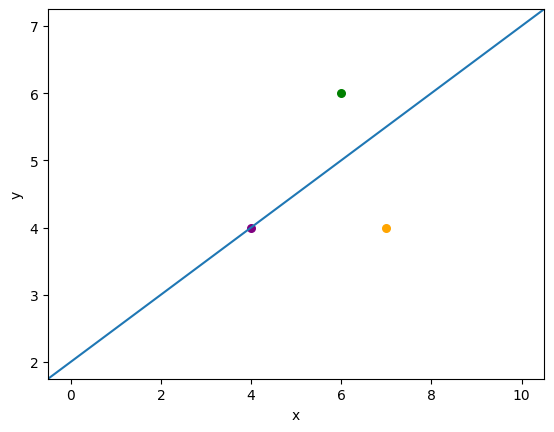

In [73]:
draw_example()

Do tego celu potrzebujesz wygenerować zbiory punktów testowych.


# Generowanie losowych punktów na płaszczyźnie

Uzupełnij funkcję ```generate_uniform_points```
 (Aby generować losowo liczby rzeczywiste bardzo przydatna może okazać się jakaś funckja biblioteczna)

In [8]:

def generate_uniform_points(left, right, n = 10 ** 5):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym obszarze od left do right (jednakowo na osi y) o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    rnd = np.random.default_rng(seed=(9835))
    x = rnd.uniform(left,right,n)
    y = rnd.uniform(left,right,n)
    return list(zip(x,y))

<span style="color:red">Ćw.</span> Wygeneruj $10^5$ losowych punktów w przestrzeni 2D o współrzędnych z przedziału $x, y \in \left[-1000,1000\right]^{2}$.

In [9]:
points_a = generate_uniform_points(-1000, 1000, 10 ** 5)

Zwizualizuj wygenerowane punkty

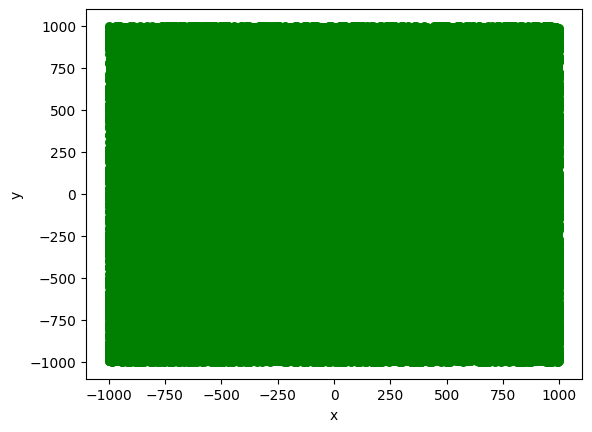

In [10]:
draw_points(points_a)

<span style="color:red">Ćw.</span> Wygeneruj $10^5$ losowych punktów w przestrzeni 2D o współrzędnych z przedziału $ x, y \in \left[-10^{14},10^{14}\right]^{2}$. Uzupełnij funkcję ```generate_big_num_of_points_2D```. Sprawdź, czy różni się wizualizalnie wynik tego ćwiczenia z poprzednim.

In [11]:
points_b = generate_uniform_points(-10 ** 14, 10 ** 14, 10 ** 5)

Zwizualizuj wygenerowane punkty.

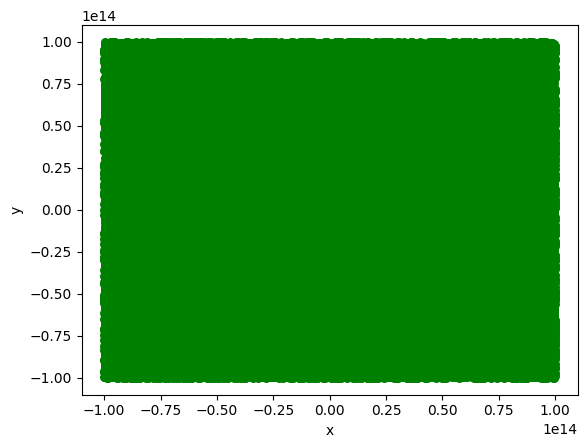

In [12]:
draw_points(points_b)

Uzupełnij funkcję ```generate_circle_points```

Zastanów się w sposób generować punkty jednostajnie na okręgu.

In [13]:
def generate_circle_points(O, R, n = 100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu 
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    rnd = np.random.default_rng(seed=9835)
    theta = rnd.uniform(0,1,n)
    x0,y0 = O
    x = x0 + R * np.cos(2* np.pi* theta)
    y = y0 + R * np.sin(2* np.pi* theta)
    output = list(zip(x,y))
    return output

<span style="color:red">Ćw.</span> Wygeneruj $ 1000$ losowych punktów w przestrzeni 2D leżących na okręgu o środku $ O = (0,0)$ i promieniu $ R = 100$. 

Uzupełnij funkcję ```generate_points_on_circle_2D```.

In [14]:
points_c = generate_circle_points((0, 0), 100, 1000)

Zwizualizuj wygenerowane punkty.

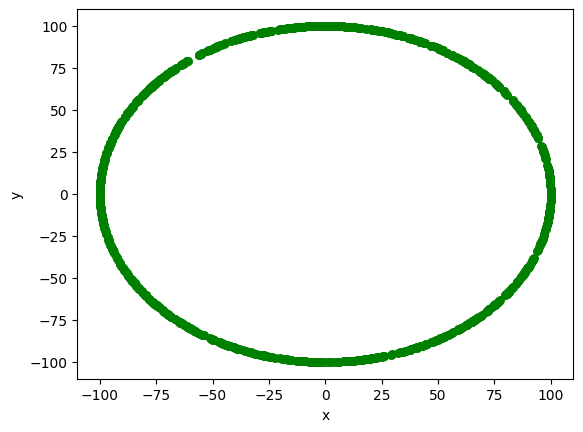

In [15]:
draw_points(points_c)

Uzupełnij funkcję ```generate_collinear_points```.

In [33]:
def generate_collinear_points(a, b, n=100):
    """
    Funkcja generuje równomiernie n współliniowych punktów leżących na prostej ab pomiędzy punktami a i b
    :param a: krotka współrzędnych oznaczająca początek wektora tworzącego prostą
    :param b: krotka współrzędnych oznaczająca koniec wektora tworzącego prostą
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    rnd = np.random.default_rng(seed=9835)
    x = rnd.uniform(-1000, 1000, n)

    x0,y0 = a
    x1,y1 = b
    A = (y1 - y0) / (x1 - x0)
    B = y0 - A * x0
    y = A * x + B
        
    return list(zip(x,y))

<span style="color:red">Ćw.</span>  Wygeneruj $ 1000$ losowych punktów w przestrzeni 2D o współrzędnej z przedziału $ x \in \langle -1000,1000 \rangle$ leżących na prostej wyznaczonej przez wektor $ \overrightarrow{ab}$. Przyjmij punkty $ a = (-1.0, 0.0)$ oraz $ b = (1.0, 0.1)$. Uzupełnij funkcję ```generate_points_on_line_2D```.

In [34]:
points_d= generate_collinear_points((-1.0, 0.0), (1.0,0.1),1000)

Zwizualizuj wygenerowane punkty.

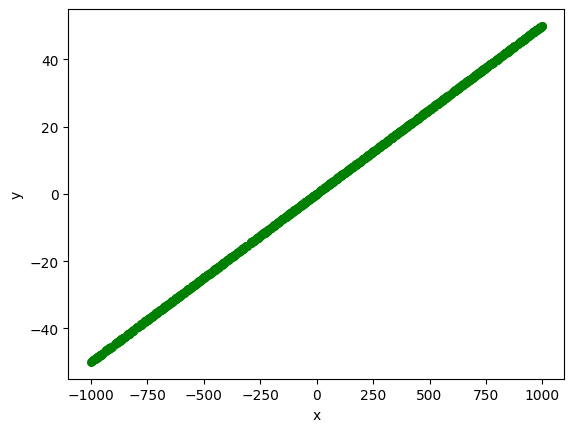

In [35]:
draw_points(points_d)

Przeprowadź test poprawności powyższych funkcji

In [ ]:
Test().runtest(1, generate_uniform_points, generate_circle_points, generate_collinear_points)

Lab 1, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
Result: 4/4
Time: 0.140s


# Po której stornie prostej znajduje się punkt?

Prostym sposobem do obliczenia, po której strnie prostej znajduje się punkt jest obliczenie iloczynu wektorowego 
$\overrightarrow{ab} \times \overrightarrow{ac}$, gdzie $ c = (x,y)$ jest punktem, dla którego poszukujemy wiadomości o lokalizacji względem prostej przechodzącej przez punkty $ a$ i $ b$. Metoda ta jest równoznaczna z obliczeniem wyznacznika macierzy $ 2\times2$:  

$$
(1)\det(a, b, c)= \begin{vmatrix}
       a_{x} - c_{x} & a_{y} - c_{y} \\
       b_{x} - c_{x} & b_{y} - c_{y} 
              \end{vmatrix}
$$


lub wyznacznika macierzy $ 3\times3$:

$$
(2)\det(a, b, c)= \begin{vmatrix}
       a_{x} & a_{y} & 1 \\
       b_{x} & b_{y} & 1 \\
       c_{x} & c_{y} & 1
              \end{vmatrix}
$$

Upraszczając tą macierz przez odjęcie drugiego wiersza od trzeciego i odjęcie pierwszego wiersza od drugiego otrzymamy:

$$
\det(a, b, c)  = \begin{vmatrix}
              a_{x}         & a_{y}         & 1 \\
              b_{x} - a_{x} & b_{y} - a_{y} & 0 \\
              c_{x} - b_{x} & c_{y} - b_{y} & 0
                     \end{vmatrix}
              = (b_{x} - a_{x})(c_{y} - b_{y}) - (b_{y} - a_{y})(c_{x} - b_{x})
$$

Jest to wzór, z który opisuje pole równoległoboku mającego boki $ ab$ oraz $ ac$ (Dowód dlaczego tak jest, do zrobienia w domu)  
Dlaczego wiemy, że po obliczeniu wskaźnika podanego powyżej będziemy wiedzieć, po której stornie prostej znajduje się punkt?</font>
<font size="1">
</br>
***

**Dowód**:  

Załóżmy, że mamy dane trzy punkty w przestrzeni 2-wymiarowej $A, B$ oraz $C$. Znajdujemy prostą przechodzącą przez punkty $A$ i $B$. Następnie obliczamy $C_{y}$ przy danym $C_{x}$ i sprawdzamy czy punkt leży nad czy pod prostą.
Współczynnik nachylenia prostej jest nastepujący:

$$a = \frac{B_{y} - A_{y}}{B_{x} - A_{x}}
$$
Natomiast współczynnik $b$ wynosi:

$$b = B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}
$$

Po wpisaniu do równania $y = ax + b$ wyliczonego nachylenia prostej, współczynnika $b$ oraz zmiennej $C_{x}$ otrzymujemy:

$$y = \left(\frac{B_{y} - A_{y}}{B_{x} - A_{x}}\right)C_{x}+ \left(B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}\right)
$$

Otzymujemy punkt $C$ po lewej stronie prostej jeżeli $C_{y} - y > 0$, po prawej jeżeli $C_{y} - y < 0$, a punkt $C$ leżący na prostej, jeżeli $C_{y} - y = 0$. Przekształcimy powyższe równanie dla $C_{y} - y > 0$:

$$C_{y} - y > 0$$ 
$$C_{y} - \left(\frac{B_{y} - A_{y}}{B_{x} - A_{x}}\right)C_{x} - \left(B_{y} - \frac{(B_{y} - A_{y})B_{x}}{B_{x} - A_{x}}\right) > 0$$
$$C_{y}(B_{x} - A_{x}) - C_{x}(B_{y} - A_{y}) - B_{y}(B_{x} - A_{x}) + B_{x}(B_{y} - A_{y}) > 0$$
$$(C_{y} - B_{y})(B_{x} - A_{x}) + (B_{x} - C_{x})(B_{y} - A_{y}) > 0$$ 
$$(C_{y} - B_{y})(B_{x} - A_{x}) - (C_{x} - B_{x})(B_{y} - A_{y}) > 0$$

Zatem widzimy, że ostatnie równie jest takie same co przy równaniu wyznacznika macierzy $3\times3$. Niejawnie założyliśmy tutaj, że $B_{x}$ jest wieksze od $A_{x}$ , jeżeli byłoby odwrotnie zmieniłby się tylko znak nierówności na przeciwny. W naszym przypadku pokazaliśmy, że $C$ znajduje się po lewej stronie prostej jeżeli wyznacznik jest dodatni oraz po prawej stronie prostej, jeżeli wyznacznik jest ujemny. $Q.E.D$

---
Kolejnym zadaniem będzie zaimplementowanie własnych wyznaczników $(1)$ oraz $(2)$ i porówanie ich szybkości działania z wyznacznikami bibliotecznymi w testowaniu dla różnych zbiorów punktów. Co dodatkowo chcemy sprawdzić, czy wszystkie wyznaczniki podobnie kwalifikują podział względem danej lini.

Uzupełnij funkcje ```mat_det_3x3```

In [39]:
def mat_det_3x3(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """

    ax,ay = a
    bx,by = b
    cx,cy = c

    return ax * by + ay * cx + bx * cy - (ay * bx + ax * cy + by * cx)

Uzupełnij funkcję ```mat_det_3x3_lib```, ale tym razem wykorzystaj dowolną funckję biblioteczną do obliczenia wyznacznika

In [40]:
def mat_det_3x3_lib(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 z użyciem funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    A = np.array([[a[0],a[1],1],[b[0],b[1],1],[c[0],c[1],1]])
    return np.linalg.det(A)

Uzupełnij funkcje ```mat_det_2x2```

In [41]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (b[0]-a[0])*(c[1]-b[1])-(b[1]-a[1])*(c[0]-b[0])

Uzupełnij funkcję ```mat_det_2x2_lib```, ale tym razem wykorzystaj dowolną funckję biblioteczną do obliczenia wyznacznika

In [42]:
def mat_det_2x2_lib(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 z użyciem funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    A = np.array([[a[0]-c[0],a[1]-c[1]],[b[0]-c[0],b[1]-c[1]]])
    return np.linalg.det(A)

Przetestujmy napisane powyżej funkcje.

In [ ]:
Test().runtest(2, mat_det_3x3, mat_det_2x2, mat_det_3x3_lib, mat_det_2x2_lib)

Lab 1, task 2:
	Test 1: Passed
	Test 2: Passed
Result: 2/2
Time: 0.003s


<span style="color:red">Ćw.</span> Klasyfikacja punktów względem prostej - zaimplementuj funkcję ```categorize_points```, która skwalifukuje punkty względem prostej wyznacznonej przez wektor $\large \overrightarrow{ab}$ (prosta przechodząca przez punkty $\large a$ oraz $\large b$.

In [55]:
def categorize_points(points, a, b, mat_det_func, eps):
    """
    :param points: tablica punktów w postaci krotek współrzednych
    :param a: krotka współrzędnych oznaczająca początek odcinka
    :param b: krotka współrzędnych oznaczająca koniec odcinka
    :param mat_det_func: funkcja która będzie tutaj używana do obliczenia wyznacznika macierzy
    :param eps: epsilon - jak blisko wyznacznik macierzy ma być blisko zera, aby uznać punkt za leżący na prostej
    :return: 3 tablice zawierające kolejno zbiory punktów: leżące na lewo od prostej, leżące na prostej, leżące na prawo od prostek
    """
    output = [[],[],[]]
    for p in points:
        classification = mat_det_func(a,b,p)
        if abs(classification) <= eps:
            output[1].append(p)
        elif classification > 0:
            output[0].append(p)
        else:
            output[2].append(p)
    return output

In [56]:
a = (-1.0, 0.0)
b = (1.0, 0.1)

Zwizualizuj sklasyfikowane punkty. Punkty różnią się kolorami ze względu na klasyfikację: na lewo od prostej - zielone, na prostej - fioletowe, na prawo - pomarańczowe.

In [57]:
classified_points_a_left,classified_points_a_mid,classified_points_a_right = categorize_points(points_a, a, b, mat_det_2x2_lib, 10 ** -12)

Liczba punktow po lewej 50060
Liczba punktow na lini 0
Liczba punktow po prawej 49940


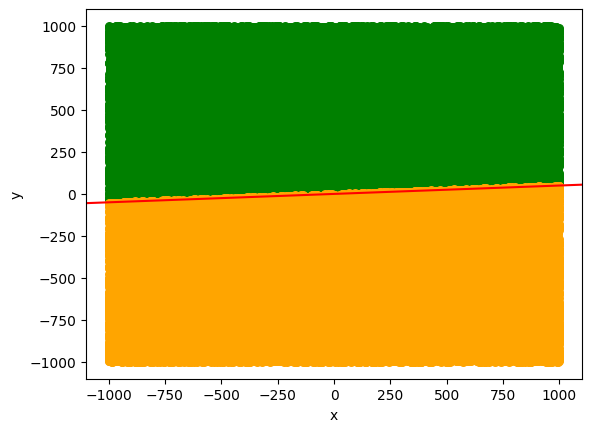

In [58]:
draw_line(classified_points_a_left, classified_points_a_mid, classified_points_a_right)
print("Liczba punktow po lewej", len(classified_points_a_left))
print("Liczba punktow na lini",len(classified_points_a_mid))
print("Liczba punktow po prawej",len(classified_points_a_right))

In [59]:
classified_points_b_left,classified_points_b_mid,classified_points_b_right = categorize_points(points_b, a, b, mat_det_2x2_lib, 10**-12)

Liczba punktow po lewej 50063
Liczba punktow na lini 0
Liczba punktow po prawej 49937


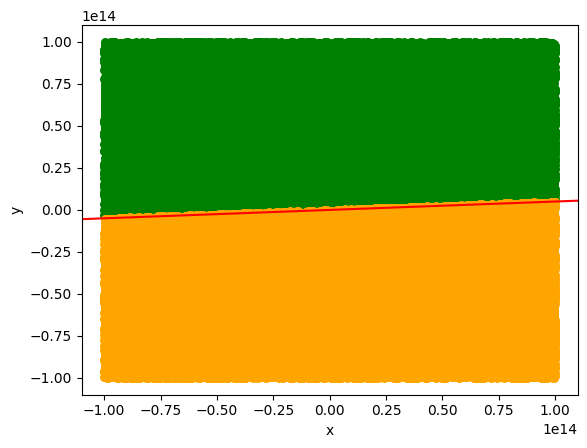

In [60]:
draw_line(classified_points_b_left, classified_points_b_mid, classified_points_b_right)
print("Liczba punktow po lewej", len(classified_points_b_left))
print("Liczba punktow na lini",len(classified_points_b_mid))
print("Liczba punktow po prawej",len(classified_points_b_right))

In [61]:
classified_points_c_left,classified_points_c_mid,classified_points_c_right = categorize_points(points_c, a, b, mat_det_2x2, 10 ** -12)

Liczba punktow po lewej 510
Liczba punktow na lini 0
Liczba punktow po prawej 490


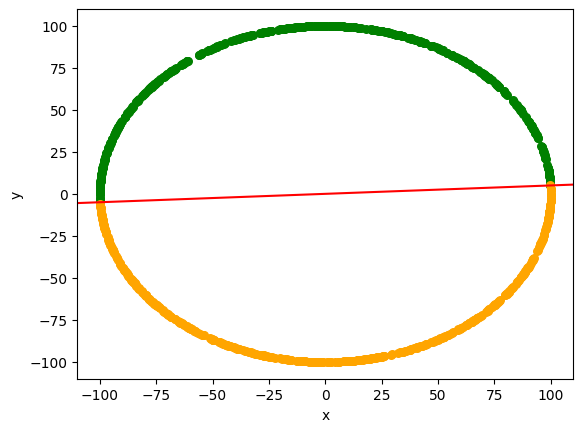

In [62]:
draw_line(classified_points_c_left, classified_points_c_mid, classified_points_c_right)
print("Liczba punktow po lewej", len(classified_points_c_left))
print("Liczba punktow na lini",len(classified_points_c_mid))
print("Liczba punktow po prawej",len(classified_points_c_right))

In [63]:
classified_points_d_left,classified_points_d_mid,classified_points_d_right = categorize_points(points_d, a, b, mat_det_2x2, 10**-8)

Liczba punktow po lewej 0
Liczba punktow na lini 1000
Liczba punktow po prawej 0


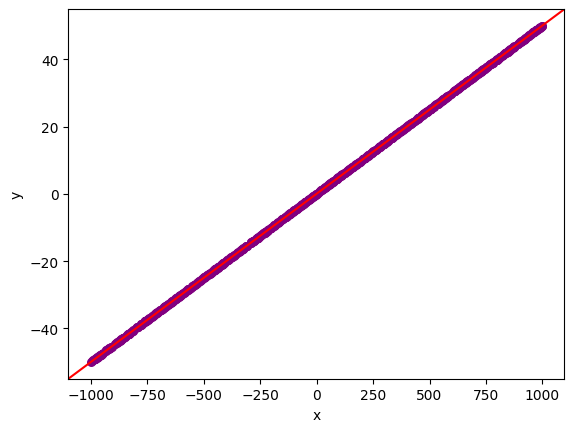

In [64]:
draw_line(classified_points_d_left, classified_points_d_mid, classified_points_d_right)
print("Liczba punktow po lewej", len(classified_points_d_left))
print("Liczba punktow na lini",len(classified_points_d_mid))
print("Liczba punktow po prawej",len(classified_points_d_right))

Przeprowadźmy teraz testy dla mniejszej precyzji obliczeń. Do tego celu należy zmiejszyć typ danych z float64 (domyślny typ floata w pythonie) na float32. Różnią się one tym, że float32 jest zapisywane na mniejszej ilości bitów, co przekłada się no mniejszą ilosć cyfr po przecinku.
Zamienić typ floata w całej tablicy można zrobić w następujący sposób:

Liczba punktow po lewej 50060
Liczba punktow na lini 0
Liczba punktow po prawej 49940


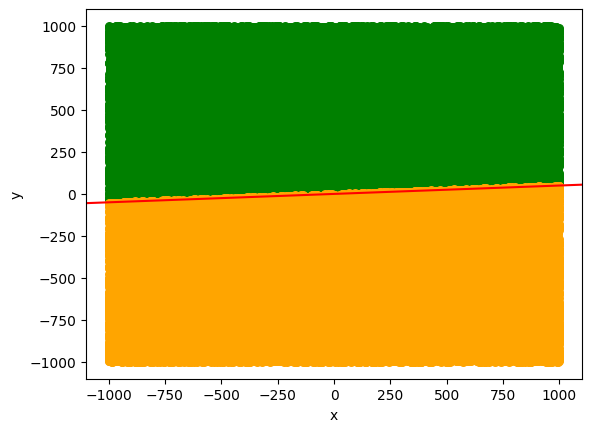

In [65]:
points_a_float32 = np.float32(points_a)
classified_points_a_float32_left,classified_points_a_float32_mid,classified_points_a_float32_right = categorize_points(points_a_float32, a, b, mat_det_3x3, 10 ** -12)
draw_line(classified_points_a_left, classified_points_a_mid, classified_points_a_right)
print("Liczba punktow po lewej", len(classified_points_a_left))
print("Liczba punktow na lini",len(classified_points_a_mid))
print("Liczba punktow po prawej",len(classified_points_a_right))

Funkcja generująca wszystkie klasyfikacje dla okreslonego zbioru punktów


In [69]:
import numpy as np

def generate_class(points, a, b, name_prefix="x"):
    result = {
        "f64": {"3x3": {}, "3x3_lib": {}, "2x2": {}, "2x2_lib": {}},
        "f32": {"3x3": {}, "3x3_lib": {}, "2x2": {}, "2x2_lib": {}}
    }
    
    points_f32 = np.float32(points)

    det_funcs = {
        "3x3": mat_det_3x3,
        "3x3_lib": mat_det_3x3_lib,
        "2x2": mat_det_2x2,
        "2x2_lib": mat_det_2x2_lib
    }

    epsilons = [10**-10, 10**-12, 10**-14,0]
    eps_key = ["-10","-12","-14",0]

    for key, func in det_funcs.items():
        for i,eps in enumerate(epsilons):
            # f64
            result["f64"][key][eps_key[i]] = categorize_points(points, a, b, func, eps)
            # f32
            result["f32"][key][eps_key[i]] = categorize_points(points_f32, a, b, func, eps)
    return result


Funkcja eksportująca dane do pliku .csv


In [67]:
def export_results(data,name):
    rows = [["type", "matrix", "epsilon", "l","m","r"]]

    for dtype, matrices in data.items():
        for matrix, epsilons in matrices.items():
            for eps, value in epsilons.items():
                rows.append([dtype, matrix, eps, len(value[0]),len(value[1]),len(value[2])])

    # zapis hurtem — dużo szybciej
    with open(f'{name}.csv', "w", newline="", encoding="utf-8") as f:
        f.write("\n".join(",".join(map(str, row)) for row in rows))

Generacja klasyfikacji dla wszystkich zbiorów punków

In [70]:
a_class = generate_class(points_a,a,b)
b_class = generate_class(points_b,a,b)
c_class = generate_class(points_c,a,b)
d_class = generate_class(points_d,a,b)

Eksport wyników

In [71]:
export_results(a_class,"a_class")
export_results(b_class,"b_class")
export_results(c_class,"c_class")
export_results(d_class,"d_class")

# Generowanie wykresów do sprawozdania 


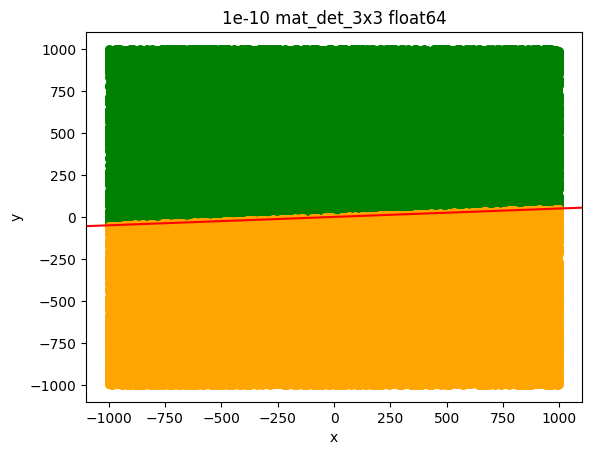

In [77]:
left, mid, right = a_class["f64"]["3x3"]["-10"]
draw_line(left,mid,right,"1e-10 mat_det_3x3 float64")

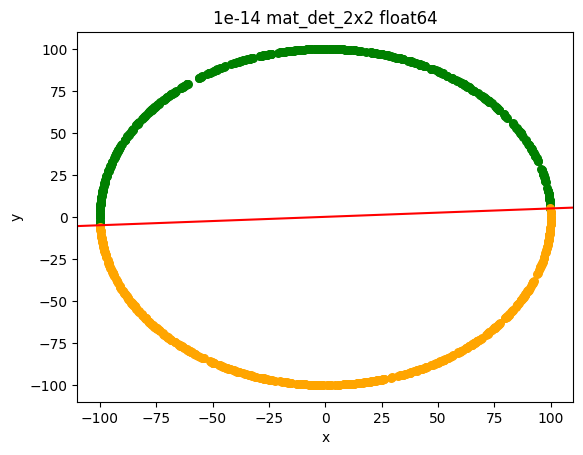

In [85]:
left, mid, right = c_class["f64"]["2x2"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_2x2 float64")

In [84]:
adiff = np.setdiff1d(b_class["f64"]["2x2_lib"]["-12"][0],b_class["f64"]["2x2"]["-12"][0])
print(adiff)

[4.93248039e+12 9.88848173e+13]


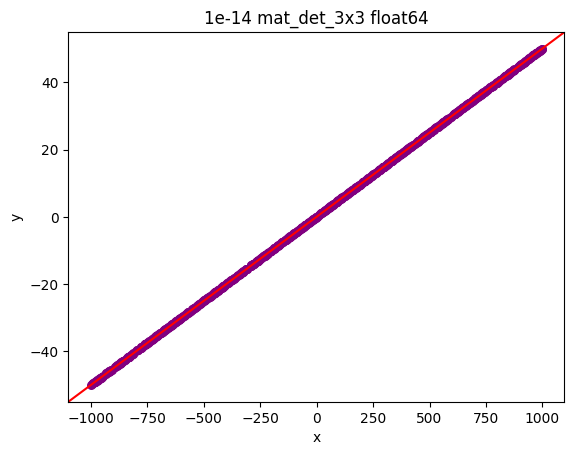

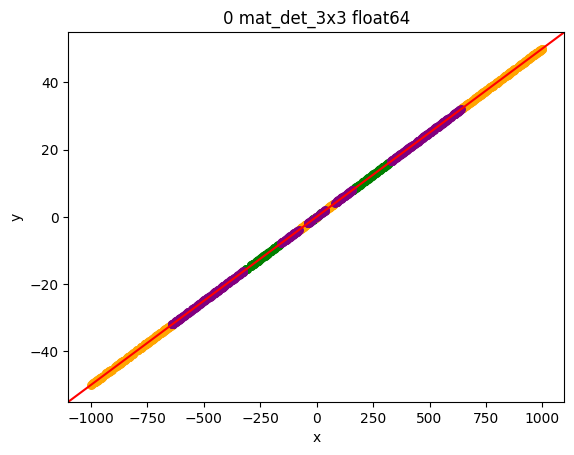

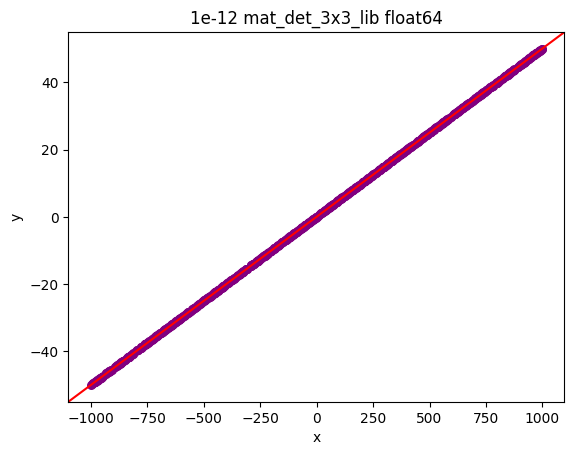

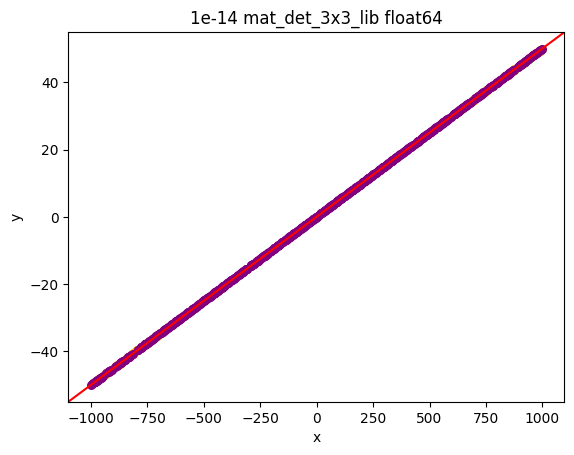

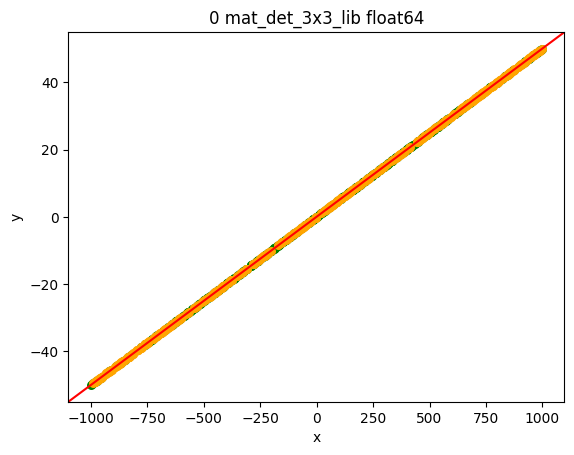

In [88]:
left, mid, right = d_class["f64"]["3x3"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_3x3 float64")
left, mid, right = d_class["f64"]["3x3"][0]
draw_line(left,mid,right,"0 mat_det_3x3 float64")
left, mid, right = d_class["f64"]["3x3_lib"]["-10"]
draw_line(left,mid,right,"1e-12 mat_det_3x3_lib float64")
left, mid, right = d_class["f64"]["3x3_lib"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_3x3_lib float64")
left, mid, right = d_class["f64"]["3x3_lib"][0]
draw_line(left,mid,right,"0 mat_det_3x3_lib float64")

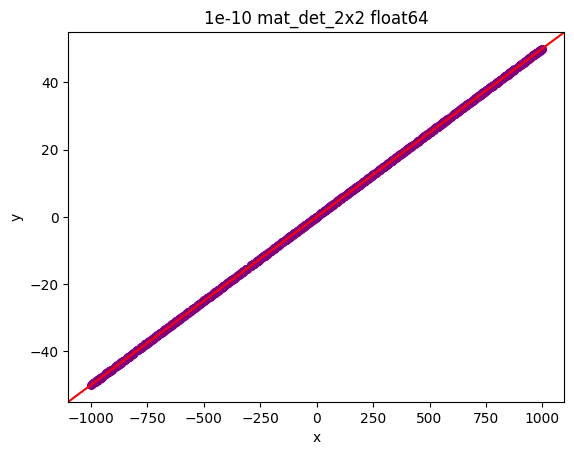

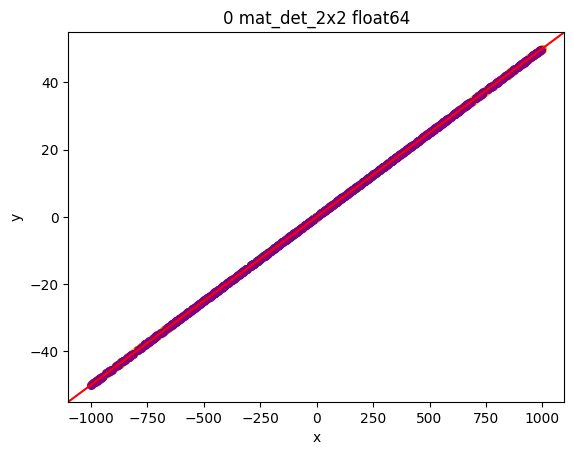

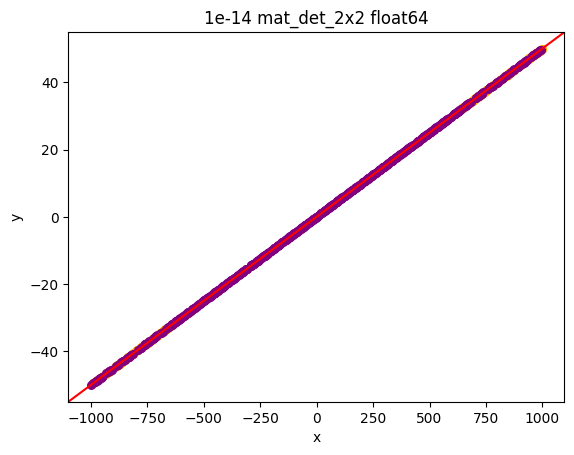

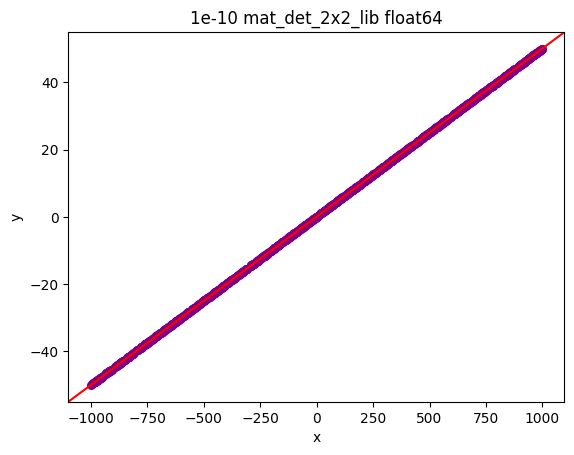

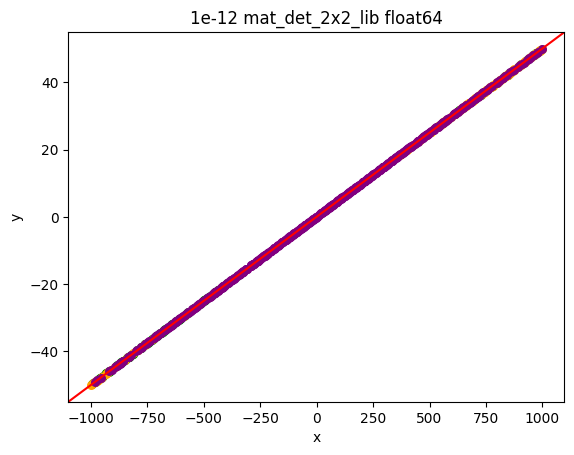

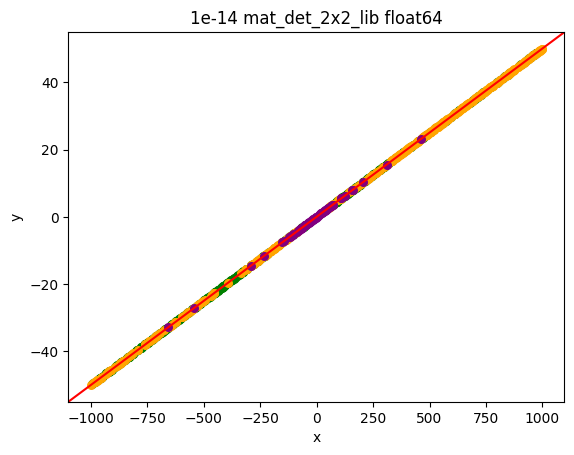

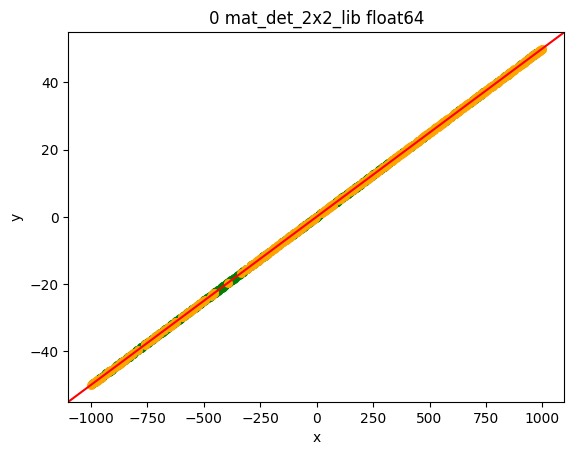

In [89]:
left, mid, right = d_class["f64"]["2x2"]["-10"]
draw_line(left,mid,right,"1e-10 mat_det_2x2 float64")
left, mid, right = d_class["f64"]["2x2"][0]
draw_line(left,mid,right,"0 mat_det_2x2 float64")
left, mid, right = d_class["f64"]["2x2"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_2x2 float64")
left, mid, right = d_class["f64"]["2x2_lib"]["-10"]
draw_line(left,mid,right,"1e-10 mat_det_2x2_lib float64")
left, mid, right = d_class["f64"]["2x2_lib"]["-12"]
draw_line(left,mid,right,"1e-12 mat_det_2x2_lib float64")
left, mid, right = d_class["f64"]["2x2_lib"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_2x2_lib float64")
left, mid, right = d_class["f64"]["2x2_lib"][0]
draw_line(left,mid,right,"0 mat_det_2x2_lib float64")

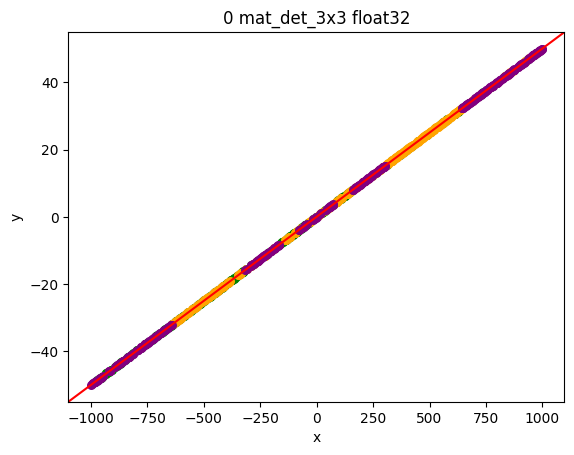

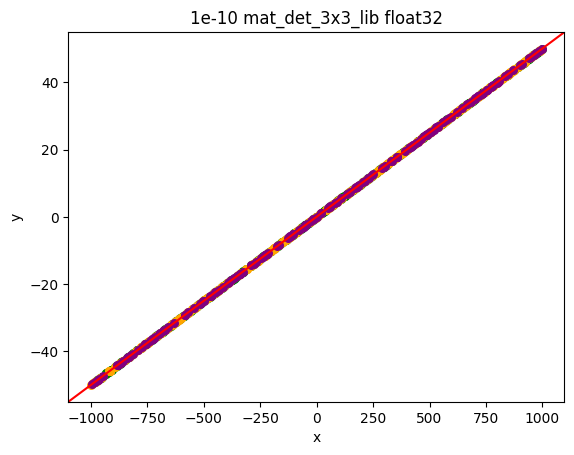

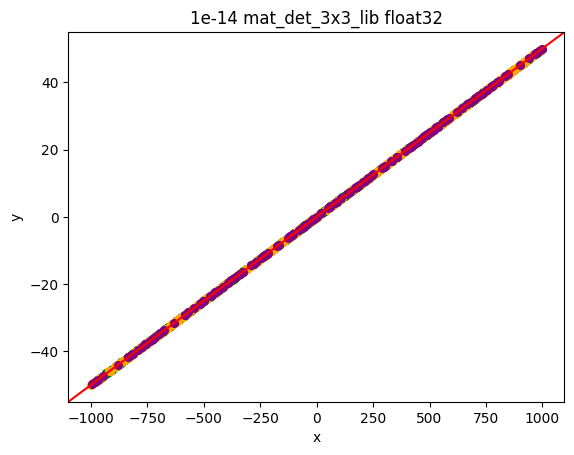

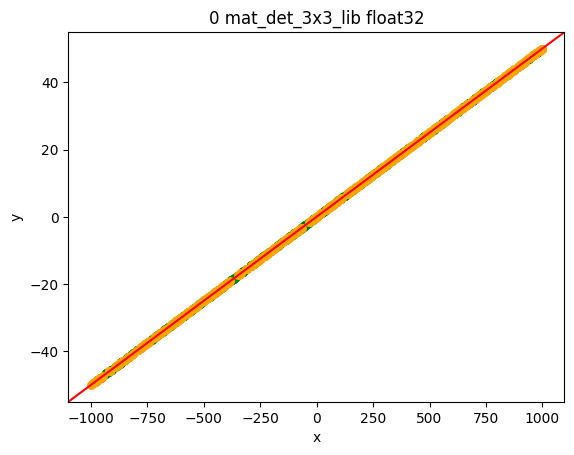

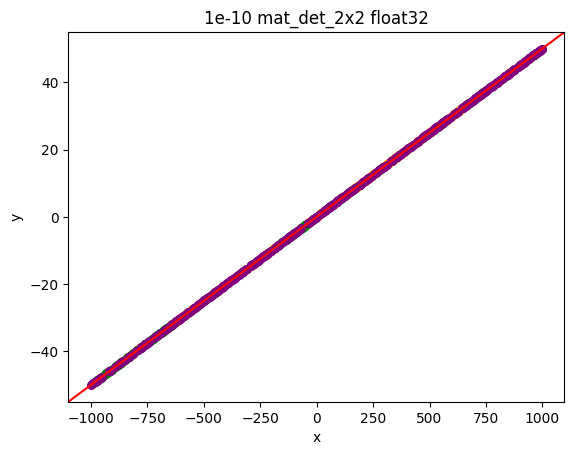

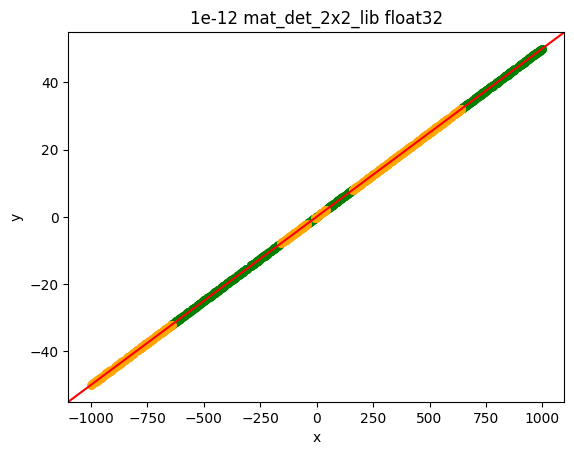

In [90]:
left, mid, right = d_class["f32"]["3x3"][0]
draw_line(left,mid,right,"0 mat_det_3x3 float32")
left, mid, right = d_class["f32"]["3x3_lib"]["-10"]
draw_line(left,mid,right,"1e-10 mat_det_3x3_lib float32")
left, mid, right = d_class["f32"]["3x3_lib"]["-14"]
draw_line(left,mid,right,"1e-14 mat_det_3x3_lib float32")
left, mid, right = d_class["f32"]["3x3_lib"][0]
draw_line(left,mid,right,"0 mat_det_3x3_lib float32")
left, mid, right = d_class["f32"]["2x2"]["-10"]
draw_line(left,mid,right,"1e-10 mat_det_2x2 float32")
left, mid, right = d_class["f32"]["2x2_lib"]["-12"]
draw_line(left,mid,right,"1e-12 mat_det_2x2_lib float32")



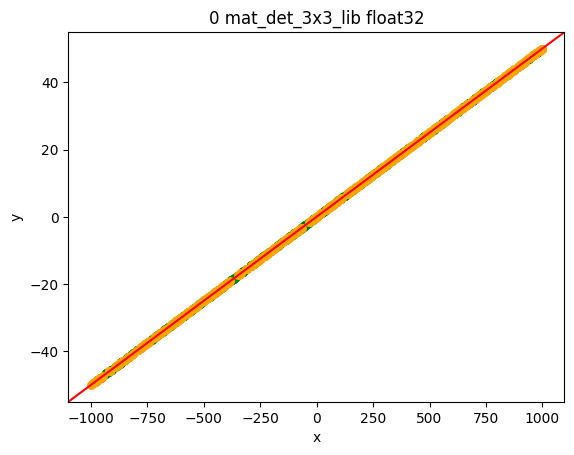

In [91]:
left,mid,rigth = d_class["f32"]["3x3_lib"][0]
draw_line(left,mid,rigth,"0 mat_det_3x3_lib float32")